#**Importing Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

#Loading datasets

In [5]:
transaction = pd.read_excel("QVI_transaction_data.xlsx")
behaviour = pd.read_csv("QVI_purchase_behaviour.csv")

#*Basic Exploration*

In [6]:
transaction.head()

transaction.info()

transaction.describe()

transaction.shape

transaction.isnull().sum()

transaction.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264836 entries, 0 to 264835
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   DATE            264836 non-null  int64  
 1   STORE_NBR       264836 non-null  int64  
 2   LYLTY_CARD_NBR  264836 non-null  int64  
 3   TXN_ID          264836 non-null  int64  
 4   PROD_NBR        264836 non-null  int64  
 5   PROD_NAME       264836 non-null  object 
 6   PROD_QTY        264836 non-null  int64  
 7   TOT_SALES       264836 non-null  float64
dtypes: float64(1), int64(6), object(1)
memory usage: 16.2+ MB


np.int64(1)

#changing date format

In [8]:
transaction["DATE"] = pd.to_datetime(
    transaction["DATE"],
    unit="D",
    origin="1899-12-30"
)

#<u>Insight:</u>

1.   No missing values found.
2. Data types were appropriate after converting the DATE column







In [9]:
transaction.info()
transaction.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264836 entries, 0 to 264835
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   DATE            264836 non-null  datetime64[ns]
 1   STORE_NBR       264836 non-null  int64         
 2   LYLTY_CARD_NBR  264836 non-null  int64         
 3   TXN_ID          264836 non-null  int64         
 4   PROD_NBR        264836 non-null  int64         
 5   PROD_NAME       264836 non-null  object        
 6   PROD_QTY        264836 non-null  int64         
 7   TOT_SALES       264836 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(5), object(1)
memory usage: 16.2+ MB


,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8


In [7]:
behaviour.head()

behaviour.info()

behaviour.describe()

behaviour.shape

behaviour.isnull().sum()

behaviour.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72637 entries, 0 to 72636
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   LYLTY_CARD_NBR    72637 non-null  int64 
 1   LIFESTAGE         72637 non-null  object
 2   PREMIUM_CUSTOMER  72637 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


np.int64(0)

#*Descriptive Statistics*

In [10]:
transaction.describe()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_QTY,TOT_SALES
count,264836,264836.00000,2.648360e+05,2.648360e+05,264836.000000,264836.000000,264836.000000
mean,2018-12-30 00:52:12.879215616,135.08011,1.355495e+05,1.351583e+05,56.583157,1.907309,7.304200
min,2018-07-01 00:00:00,1.00000,1.000000e+03,1.000000e+00,1.000000,1.000000,1.500000
25%,2018-09-30 00:00:00,70.00000,7.002100e+04,6.760150e+04,28.000000,2.000000,5.400000
50%,2018-12-30 00:00:00,130.00000,1.303575e+05,1.351375e+05,56.000000,2.000000,7.400000
75%,2019-03-31 00:00:00,203.00000,2.030942e+05,2.027012e+05,85.000000,2.000000,9.200000
max,2019-06-30 00:00:00,272.00000,2.373711e+06,2.415841e+06,114.000000,200.000000,650.000000
std,NaN,76.78418,8.057998e+04,7.813303e+04,32.826638,0.643654,3.083226


In [11]:
transaction["PROD_QTY"].value_counts().sort_index()

,count
PROD_QTY,
1,27518
2,236039
3,430
4,397
5,450
200,2


In [12]:
transaction["TOT_SALES"].describe()

,TOT_SALES
count,264836.000000
mean,7.304200
std,3.083226
min,1.500000
25%,5.400000
50%,7.400000
75%,9.200000
max,650.000000


#Verifying Outliers

In [13]:
transaction[transaction["PROD_QTY"] == 200]

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
69762,2018-08-19,226,226000,226201,4,Dorito Corn Chp Supreme 380g,200,650.0
69763,2019-05-20,226,226000,226210,4,Dorito Corn Chp Supreme 380g,200,650.0


#Removing Outliers

In [14]:
transaction = transaction[transaction["PROD_QTY"] != 200]

#<u>Insight:</u>
Two transactions with PROD_QTY = 200 were identified as bulk purchases and removed because they do not represent typical consumer behaviour

# Verifying for Salsa Product

In [16]:
transaction[transaction["PROD_NAME"].str.contains("Salsa", case=False)]

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
5,2019-05-19,4,4074,2982,57,Old El Paso Salsa Dip Tomato Mild 300g,1,5.1
25,2019-05-15,39,39144,35506,57,Old El Paso Salsa Dip Tomato Mild 300g,1,5.1
32,2019-05-20,45,45127,41122,64,Red Rock Deli SR Salsa & Mzzrlla 150g,2,5.4
44,2018-08-18,56,56013,50090,39,Smiths Crinkle Cut Tomato Salsa 150g,1,2.6
63,2019-05-15,82,82480,82047,101,Doritos Salsa Medium 300g,1,2.6
...,...,...,...,...,...,...,...,...
264675,2019-04-20,265,265103,263419,59,Old El Paso Salsa Dip Tomato Med 300g,1,5.1
264678,2019-03-30,265,265111,263428,35,Woolworths Mild Salsa 300g,1,1.5
264719,2018-10-28,266,266278,264104,39,Smiths Crinkle Cut Tomato Salsa 150g,1,2.6
264734,2019-01-11,267,267324,264374,41,Doritos Salsa Mild 300g,1,2.6


#Removing Salsa Products

In [17]:
transaction = transaction[
    ~transaction["PROD_NAME"].str.contains("Salsa", case=False)
]

#<u>Insight:</u>

Removed 18,094 salsa transactions since the analysis focuses on chip purchases

In [19]:
transaction.shape

(246740, 8)

#**Feature Enigneering**

#Extract Pack Size

In [20]:
transaction["PACK_SIZE"] = (
    transaction["PROD_NAME"]
    .str.extract(r'(\d+)')
    .astype(int)
)

In [21]:
transaction["PACK_SIZE"].value_counts().sort_index()

,count
PACK_SIZE,
70,1507
90,3008
110,22387
125,1454
134,25102
135,3257
150,40203
160,2970
165,15297


#Extract Brand

In [22]:
transaction["BRAND"] = transaction["PROD_NAME"].str.split().str[0]

In [23]:
transaction["BRAND"].value_counts()

,count
BRAND,
Kettle,41288
Smiths,27390
Pringles,25102
Doritos,22041
Thins,14075
RRD,11894
Infuzions,11057
WW,10320
Cobs,9693


#Brand Cleaning

In [24]:
transaction["BRAND"] = transaction["BRAND"].replace({
    "Dorito": "Doritos",
    "Red": "RRD",
    "Smith": "Smiths",
    "Infzns": "Infuzions",
    "Snbts": "Sunbites",
    "Grain": "Grain Waves",
    "GrnWves": "Grain Waves",
    "Natural": "Natural Chip Co",
    "NCC": "Natural Chip Co",
    "Burger": "Burger Rings",
    "French": "French Fries",
    "WW": "Woolworths"
})

In [25]:
transaction["BRAND"].value_counts()

,count
BRAND,
Kettle,41288
Smiths,30353
Doritos,25224
Pringles,25102
RRD,16321
Infuzions,14201
Thins,14075
Woolworths,11836
Cobs,9693


#<u>Insight:</u>
Standardized inconsistent brand names (e.g., Dorito → Doritos, Smith → Smiths) to ensure accurate brand-level analysis.

#**Merging the datasets**

In [26]:
df = transaction.merge(
    behaviour,
    on="LYLTY_CARD_NBR",
    how="left"
)

In [28]:
df.shape

(246740, 12)

In [29]:
df.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND,LIFESTAGE,PREMIUM_CUSTOMER
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,175,Natural Chip Co,YOUNG SINGLES/COUPLES,Premium
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,175,CCs,MIDAGE SINGLES/COUPLES,Budget
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,170,Smiths,MIDAGE SINGLES/COUPLES,Budget
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0,175,Smiths,MIDAGE SINGLES/COUPLES,Budget
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8,150,Kettle,MIDAGE SINGLES/COUPLES,Budget


#**Analysis the dataset**

# 1. Total Sales by Lifestage

In [30]:
sales_lifestage = (
    df.groupby("LIFESTAGE")["TOT_SALES"]
      .sum()
      .sort_values(ascending=False)
)

print(sales_lifestage)

LIFESTAGE
OLDER SINGLES/COUPLES     376019.65
RETIREES                  342381.90
OLDER FAMILIES            328519.90
YOUNG FAMILIES            294627.90
YOUNG SINGLES/COUPLES     243756.60
MIDAGE SINGLES/COUPLES    172523.80
NEW FAMILIES               47347.95
Name: TOT_SALES, dtype: float64


#Visualizing

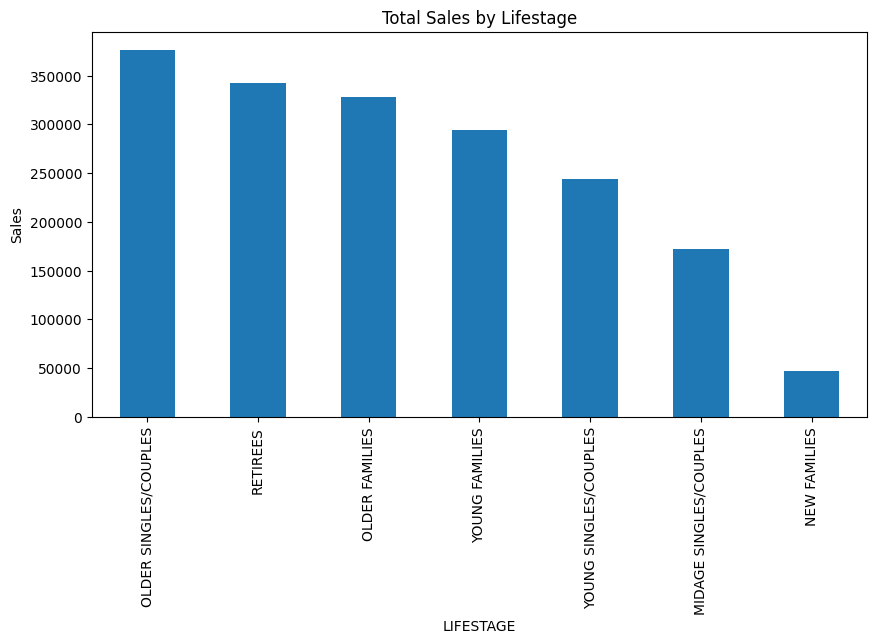

In [31]:
sales_lifestage.plot(kind="bar", figsize=(10,5))
plt.title("Total Sales by Lifestage")
plt.ylabel("Sales")
plt.show()

# 2. Total Sales by Premium Customers

In [32]:
sales_premium = (
    df.groupby("PREMIUM_CUSTOMER")["TOT_SALES"]
      .sum()
      .sort_values(ascending=False)
)

print(sales_premium)

PREMIUM_CUSTOMER
Mainstream    700865.40
Budget        631406.85
Premium       472905.45
Name: TOT_SALES, dtype: float64


#3. Number of Transactions

In [33]:
transactions = (
    df.groupby("LIFESTAGE")["TXN_ID"]
      .count()
      .sort_values(ascending=False)
)

print(transactions)

LIFESTAGE
OLDER SINGLES/COUPLES     50793
RETIREES                  46431
OLDER FAMILIES            45158
YOUNG FAMILIES            40494
YOUNG SINGLES/COUPLES     33969
MIDAGE SINGLES/COUPLES    23398
NEW FAMILIES               6497
Name: TXN_ID, dtype: int64


# 4. Avarage Spend per Transactions

In [34]:
avg_spend = (
    df.groupby("LIFESTAGE")["TOT_SALES"]
      .mean()
      .sort_values(ascending=False)
)

print(avg_spend)

LIFESTAGE
OLDER SINGLES/COUPLES     7.402982
RETIREES                  7.373994
MIDAGE SINGLES/COUPLES    7.373442
NEW FAMILIES              7.287664
YOUNG FAMILIES            7.275841
OLDER FAMILIES            7.274899
YOUNG SINGLES/COUPLES     7.175854
Name: TOT_SALES, dtype: float64


# 5. Average Pack Sized Purchased

In [35]:
pack = (
    df.groupby("LIFESTAGE")["PACK_SIZE"]
      .mean()
      .sort_values(ascending=False)
)

print(pack)

LIFESTAGE
YOUNG SINGLES/COUPLES     176.343166
MIDAGE SINGLES/COUPLES    176.075776
RETIREES                  175.880102
OLDER SINGLES/COUPLES     175.534385
OLDER FAMILIES            175.202312
NEW FAMILIES              175.166538
YOUNG FAMILIES            174.875438
Name: PACK_SIZE, dtype: float64


# 6. Most Popular Brand

In [36]:
pack = (
    df.groupby("LIFESTAGE")["PACK_SIZE"]
      .mean()
      .sort_values(ascending=False)
)

print(pack)

LIFESTAGE
YOUNG SINGLES/COUPLES     176.343166
MIDAGE SINGLES/COUPLES    176.075776
RETIREES                  175.880102
OLDER SINGLES/COUPLES     175.534385
OLDER FAMILIES            175.202312
NEW FAMILIES              175.166538
YOUNG FAMILIES            174.875438
Name: PACK_SIZE, dtype: float64


# 7. Most Popular Pack Size

In [38]:
pack_sales = (
    df.groupby("PACK_SIZE")["TOT_SALES"]
      .sum()
      .sort_values(ascending=False)
)

print(pack_sales)

PACK_SIZE
175    485437.4
150    289681.8
134    177655.5
110    162765.4
170    146673.0
330    136794.3
165    101360.6
380     75419.6
270     55425.4
210     43048.8
250     26096.7
135     26090.4
200     16007.5
190     14412.9
160     10647.6
90       9676.4
180      8568.4
70       6852.0
220      6831.0
125      5733.0
Name: TOT_SALES, dtype: float64


# Sales by Lifestage and Premium Customer

In [39]:
segment_sales = (
    df.pivot_table(
        values="TOT_SALES",
        index="LIFESTAGE",
        columns="PREMIUM_CUSTOMER",
        aggfunc="sum"
    )
)

print(segment_sales)

PREMIUM_CUSTOMER           Budget  Mainstream    Premium
LIFESTAGE                                               
MIDAGE SINGLES/COUPLES   33345.70    84734.25   54443.85
NEW FAMILIES             20607.45    15979.70   10760.80
OLDER FAMILIES          156863.75    96413.55   75242.60
OLDER SINGLES/COUPLES   127833.60   124648.50  123537.55
RETIREES                105916.30   145168.95   91296.65
YOUNG FAMILIES          129717.95    86338.25   78571.70
YOUNG SINGLES/COUPLES    57122.10   147582.20   39052.30


# Visualizing

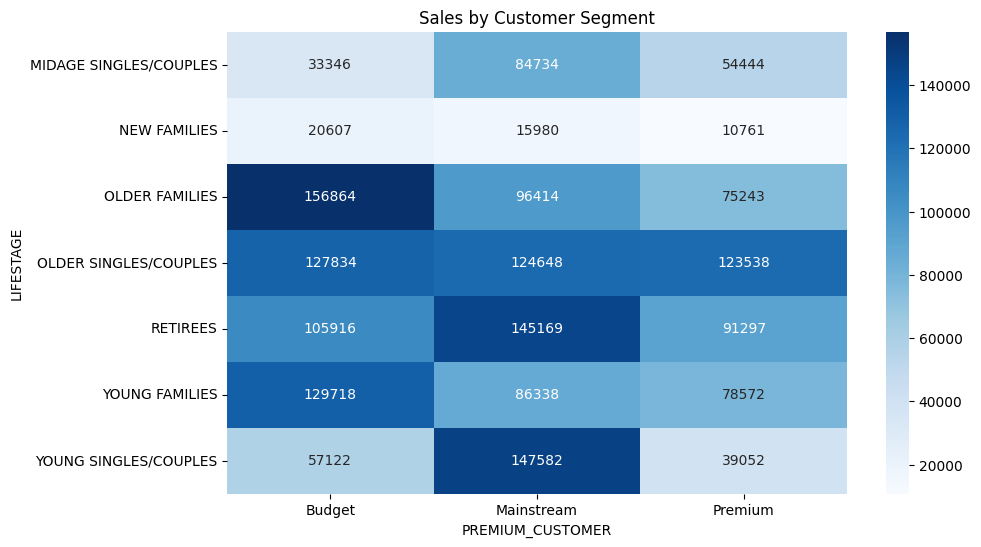

In [40]:
import seaborn as sns

plt.figure(figsize=(10,6))
sns.heatmap(segment_sales, annot=True, fmt=".0f", cmap="Blues")
plt.title("Sales by Customer Segment")
plt.show()

#<u>Insight:</u>
Mainstream young singles/couples generate the highest total chip sales, making them an attractive target segment.

#<u>Insight:</u>
 Larger pack sizes (170–175g) account for a significant share of sales, suggesting strong customer preference.

#<u>Insight:</u>
 Kettle, Smiths, and Pringles are among the top-selling brands, indicating these brands should be prioritized for promotions and shelf placement